In [1]:
import torch
import numpy as np

In [2]:
@torch.compile
def sine(x, y):
    return x.sin() @ y

In [3]:
device = torch.accelerator.current_accelerator()

In [4]:
device

device(type='mps')

In [5]:
dtype = torch.float32

In [6]:
a = torch.rand(100, 100, dtype=dtype, device=device)

In [7]:
a

tensor([[0.8894, 0.3520, 0.2149,  ..., 0.3608, 0.2197, 0.8585],
        [0.0135, 0.1083, 0.5336,  ..., 0.6021, 0.3053, 0.8975],
        [0.5986, 0.0513, 0.8603,  ..., 0.6254, 0.2355, 0.0400],
        ...,
        [0.5618, 0.8718, 0.9884,  ..., 0.2052, 0.0652, 0.3062],
        [0.1346, 0.4875, 0.9404,  ..., 0.9614, 0.9521, 0.0827],
        [0.1888, 0.8627, 0.0455,  ..., 0.4748, 0.9994, 0.8511]],
       device='mps:0')

In [8]:
b = torch.rand(100, 100, dtype=dtype, device=device)

In [9]:
result = sine(a, b)

W0602 13:36:04.391000 23538 torch/_inductor/utils.py:1731] [0/0] Not enough SMs to use max_autotune_gemm mode


In [10]:
result

tensor([[22.4933, 21.6406, 22.8148,  ..., 23.0083, 21.8858, 24.4963],
        [20.8197, 20.1804, 19.5309,  ..., 20.9153, 20.9364, 23.6639],
        [24.0060, 22.6111, 25.5852,  ..., 24.9088, 22.9617, 24.8328],
        ...,
        [21.5058, 19.5721, 19.4959,  ..., 21.3683, 19.4902, 21.4084],
        [22.8157, 20.9090, 21.3608,  ..., 22.4635, 22.7538, 22.0066],
        [22.6303, 22.2060, 23.1041,  ..., 23.7635, 23.2531, 23.6189]],
       device='mps:0')

In [11]:
artifacts = torch.compiler.save_cache_artifacts()

In [12]:
artifacts

(b'\xabb\t\xb5\x00\x00\x00\x00\x00\x00\x00\x01\x00\x00\x00\x00\x00\x00\x00\x0caW5kdWN0b3I=\x00\x00\x00\x00\x00\x00\x00\x01\x00\x00\x00\x00\x00\x00\x00HZmFrcmthYjJ4NmhxcDJjaDd2dHpyb2p3M2N3ZmtoMmNjZHRoY2Z6ZzN5a3NlNjNrYWZ1dg==\x00\x00\x00\x00\x00\x01\t~\x80\x04\x956\x00\x01\x00\x00\x00\x00\x00\x8c\x1btorch._inductor.output_code\x94\x8c\x0fCompiledFxGraph\x94\x93\x94)\x81\x94}\x94(\x8c\x10current_callable\x94N\x8c\x12compiled_fn_runner\x94N\x8c\x15recursively_apply_fns\x94N\x8c\tcache_key\x94\x8c4cbyi67w3ei75m542s6jpa473dxo6aaje2oqoknytqbcbaqx2rvuz\x94\x8c\x0bsource_code\x94X\x95\x0f\x00\x00# AOT ID: [\'0_inference\']\nfrom ctypes import c_void_p, c_long, c_int\nimport torch\nimport math\nimport random\nimport os\nimport tempfile\nfrom math import inf, nan\nfrom cmath import nanj\nfrom torch._inductor.hooks import run_intermediate_hooks\nfrom torch._inductor.utils import maybe_profile\nfrom torch._inductor.codegen.memory_planning import _align as align\nfrom torch import device, empty_stri

In [13]:
artifact_bytes, cache_info = artifacts

In [14]:
artifact_bytes

b'\xabb\t\xb5\x00\x00\x00\x00\x00\x00\x00\x01\x00\x00\x00\x00\x00\x00\x00\x0caW5kdWN0b3I=\x00\x00\x00\x00\x00\x00\x00\x01\x00\x00\x00\x00\x00\x00\x00HZmFrcmthYjJ4NmhxcDJjaDd2dHpyb2p3M2N3ZmtoMmNjZHRoY2Z6ZzN5a3NlNjNrYWZ1dg==\x00\x00\x00\x00\x00\x01\t~\x80\x04\x956\x00\x01\x00\x00\x00\x00\x00\x8c\x1btorch._inductor.output_code\x94\x8c\x0fCompiledFxGraph\x94\x93\x94)\x81\x94}\x94(\x8c\x10current_callable\x94N\x8c\x12compiled_fn_runner\x94N\x8c\x15recursively_apply_fns\x94N\x8c\tcache_key\x94\x8c4cbyi67w3ei75m542s6jpa473dxo6aaje2oqoknytqbcbaqx2rvuz\x94\x8c\x0bsource_code\x94X\x95\x0f\x00\x00# AOT ID: [\'0_inference\']\nfrom ctypes import c_void_p, c_long, c_int\nimport torch\nimport math\nimport random\nimport os\nimport tempfile\nfrom math import inf, nan\nfrom cmath import nanj\nfrom torch._inductor.hooks import run_intermediate_hooks\nfrom torch._inductor.utils import maybe_profile\nfrom torch._inductor.codegen.memory_planning import _align as align\nfrom torch import device, empty_strid

In [15]:
cache_info

CacheInfo(artifacts=defaultdict(<class 'list'>, {'inductor': ['fakrkab2x6hqp2ch7vtzrojw3cwfkh2ccdthcfzg3ykse63kafuv'], 'aot_autograd': ['amf3pr2unc6n7knasfsve3wdz6jfnvghamfzctjp4h7izgpbxamv']}))

In [16]:
x = torch.linspace(0, 5, 100, requires_grad=True)
y = (x**2).cos()

In [17]:
y

tensor([ 1.0000,  1.0000,  0.9999,  0.9997,  0.9992,  0.9980,  0.9958,  0.9922,
         0.9867,  0.9787,  0.9676,  0.9527,  0.9333,  0.9085,  0.8776,  0.8398,
         0.7943,  0.7404,  0.6775,  0.6052,  0.5231,  0.4313,  0.3299,  0.2196,
         0.1014, -0.0234, -0.1529, -0.2847, -0.4160, -0.5433, -0.6631, -0.7710,
        -0.8630, -0.9345, -0.9814, -0.9999, -0.9866, -0.9392, -0.8568, -0.7397,
        -0.5901, -0.4119, -0.2112,  0.0040,  0.2240,  0.4376,  0.6327,  0.7970,
         0.9186,  0.9874,  0.9956,  0.9389,  0.8173,  0.6357,  0.4041,  0.1375,
        -0.1447, -0.4200, -0.6645, -0.8548, -0.9709, -0.9978, -0.9285, -0.7654,
        -0.5207, -0.2169,  0.1153,  0.4393,  0.7168,  0.9122,  0.9977,  0.9577,
         0.7920,  0.5177,  0.1684, -0.2093, -0.5614, -0.8340, -0.9822, -0.9778,
        -0.8157, -0.5169, -0.1271,  0.2892,  0.6589,  0.9130,  0.9999,  0.8973,
         0.6188,  0.2141, -0.2385, -0.6461, -0.9205, -0.9975, -0.8539, -0.5153,
        -0.0541,  0.4243,  0.8049,  0.99

In [18]:
s = y.sum()

In [19]:
s

tensor(13.1082, grad_fn=<SumBackward0>)

In [20]:
[dydx] = torch.autograd.grad(s, [x])

In [21]:
[dydx]

[tensor([-0.0000e+00, -2.5765e-04, -2.0612e-03, -6.9560e-03, -1.6485e-02,
         -3.2185e-02, -5.5575e-02, -8.8145e-02, -1.3133e-01, -1.8650e-01,
         -2.5487e-01, -3.3752e-01, -4.3528e-01, -5.4869e-01, -6.7791e-01,
         -8.2262e-01, -9.8193e-01, -1.1543e+00, -1.3373e+00, -1.5279e+00,
         -1.7218e+00, -1.9138e+00, -2.0978e+00, -2.2665e+00, -2.4118e+00,
         -2.5246e+00, -2.5954e+00, -2.6144e+00, -2.5720e+00, -2.4592e+00,
         -2.2684e+00, -1.9940e+00, -1.6330e+00, -1.1861e+00, -6.5843e-01,
         -5.9786e-02,  5.9438e-01,  1.2829e+00,  1.9791e+00,  2.6508e+00,
          3.2620e+00,  3.7737e+00,  4.1467e+00,  4.3434e+00,  4.3315e+00,
          4.0872e+00,  3.5983e+00,  2.8676e+00,  1.9159e+00,  7.8273e-01,
         -4.7262e-01, -1.7729e+00, -3.0265e+00, -4.1327e+00, -4.9894e+00,
         -5.5028e+00, -5.5970e+00, -5.2252e+00, -4.3782e+00, -3.0925e+00,
         -1.4526e+00,  4.1007e-01,  2.3249e+00,  4.0956e+00,  5.5192e+00,
          6.4094e+00,  6.6222e+00,  6.

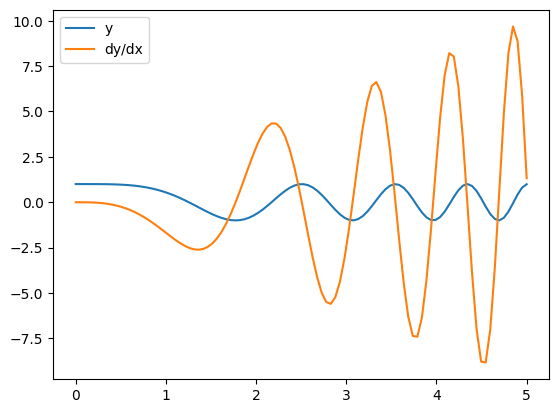

In [22]:
import matplotlib.pyplot as plt

plt.plot(x.detach(), y.detach(), label="y")
plt.plot(x.detach(), dydx, label="dy/dx")
plt.legend()
plt.show()